# Chapter 4 — A hypothesis of our own, tested and falsified

Chapter 3 argued the wall is the *signal*. But there was one escape hatch we owed the reader — and
ourselves: maybe the agent *could* learn the edge, and the reason it doesn't is that it learned the wrong
thing — it **keyed on wealth instead of the count**. This chapter is the full arc of that idea: we saw it
in the network's internal representation, we caught our own over-reading of the evidence, we built a
controlled test to settle it, and the test **falsified the hypothesis**. The wall is fundamental, not
representational — and the way we got there is the point as much as the answer.

In [1]:
import sys; sys.path.insert(0, '.')
from blackjack_rl.analysis_loader import (
    load_bet_runs, load_bet_evals, bet_provenance,
    bet_embedding, bet_project, plot_bet_embedding, plot_bet_embedding_row, plot_native_curves,
    plot_bet_replication, plot_encoding_ablation,
    plot_bet_coverage, plot_coverage_growth, coverage_four_axis, coverage_growth_ztest, coverage_visitation,
)
from IPython.display import display

runs = load_bet_runs()
evals = load_bet_evals()

# REPRESENTATIVE fixed-start probes (seed 3 in BOTH regimes — the typical case, NOT a seed that gates; the
# clustering is the same across seeds). load_bet_runs excludes the coverage sweep by default, so these are
# the fixed-start agents whose wealth artifact motivates the hypothesis.
probe_run = runs[(runs.regime == "growth") & (runs.bankroll_feature == "raw") & (runs.seed == 3)].iloc[-1]
states, embedding, bet = bet_embedding(probe_run.path)   # penultimate-layer over a (count, depth, bankroll) grid
coords = bet_project(embedding, "tsne")

probe_run_ruin = runs[(runs.regime == "ruin") & (runs.bankroll_feature == "raw")
                      & (runs.gamma == 0.95) & (~runs.double) & (runs.seed == 3)].iloc[-1]
states_r, embedding_r, bet_r = bet_embedding(probe_run_ruin.path)
coords_r = bet_project(embedding_r, "tsne")
print(f"growth probe {len(states)} states, bets {sorted(set(bet.tolist()))} | "
      f"ruin probe {len(states_r)} states, bets {sorted(set(bet_r.tolist()))}")

growth probe 760 states, bets [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0] | ruin probe 760 states, bets [1.0, 3.0, 4.0, 5.0, 6.0, 7.0]


## 4.1 The hypothesis — the representation seems to cluster by *wealth*

Take the trained network's penultimate-layer activations — its internal state representation — over a grid
of `(true count, decks remaining, bankroll)` states, and project to 2-D. Colour the same projection three
ways: by **bankroll**, by **true count**, and by the greedy **bet** the network outputs. If the agent keyed
on the edge, the structure — and the bet — should organise by *count*; if it keyed on wealth, by *bankroll*.
We do this for **both regimes** — the growth bettor (starts rich, at 400u) and the ruin bettor (starts at
200u, with the ruin barrier in play) — and read the two back to back.

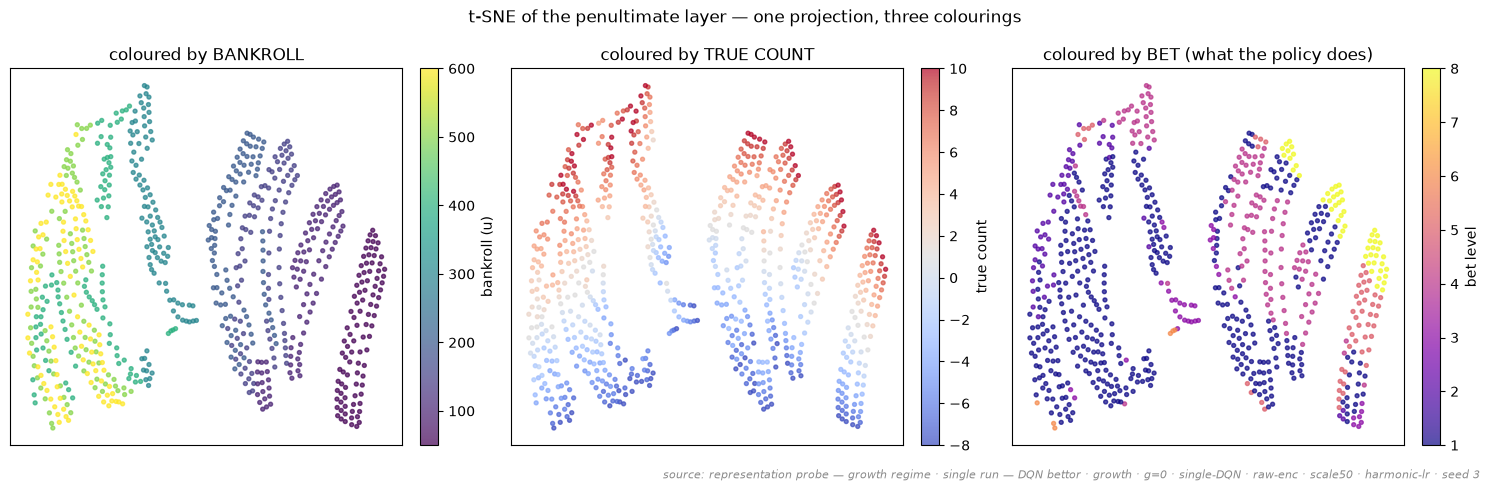

In [2]:
plot_bet_embedding_row(coords, states, bet,
                       note=bet_provenance(probe_run, role="representation probe — growth regime"))

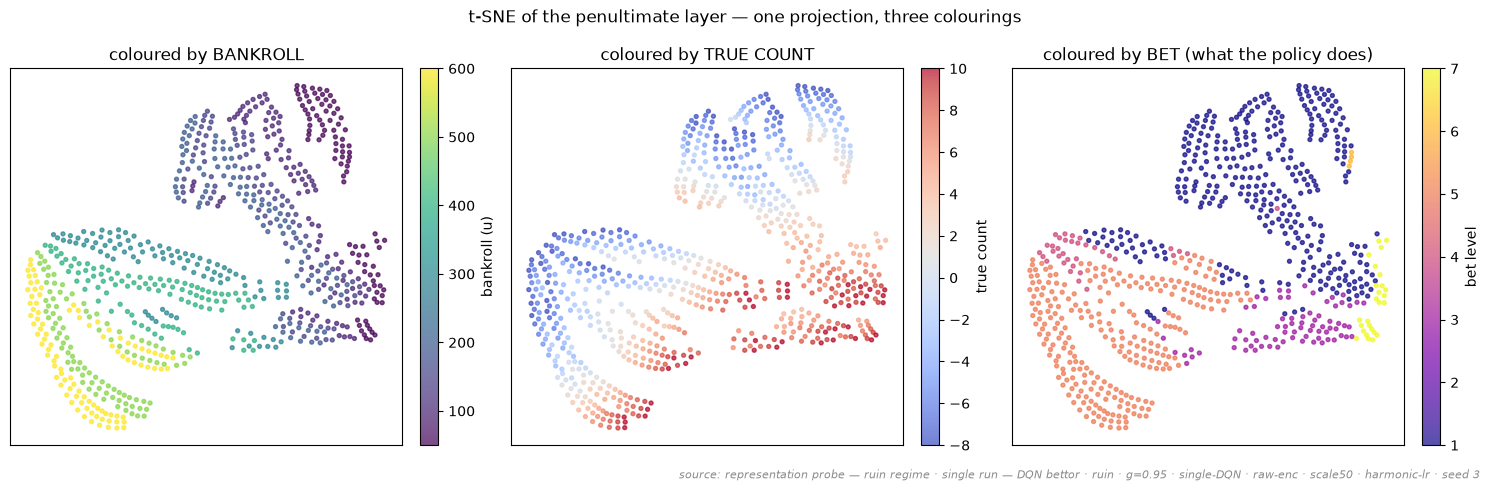

In [3]:
plot_bet_embedding_row(coords_r, states_r, bet_r,
                       note=bet_provenance(probe_run_ruin, role="representation probe — ruin regime"))

Three colourings, three tempting stories. **Bankroll** separates the clusters — *"it keyed on wealth."*
**Count** is a clean gradient within each cluster — *"no, it encoded the count."* And the **bet** panel
seems to settle it: the wager tracks position along the wealth clusters. Both regimes tell the same
clustering story — but notice the two **bet** panels are **mirror images**: the growth network bets big on
the *low*-bankroll side, the ruin network on the *high*-bankroll side. Hold onto that mirror — it is the
thread we pull in §4.5. Before believing any of these reads, we asked the only question that matters for an
embedding: **does it replicate?**

## 4.2 The over-read we caught — none of the three replicate

Two disciplines dissolved all three reads. First, **out-of-distribution**: the grid sweeps bankroll
**50–600u**, but the agents *live* at ~400u — most of that wealth axis is states the policy never occupies,
so the clean bankroll separation is largely the network extrapolating over wealth it was never evaluated at.

Second, and decisive: **replication.** If any of the structure were a real property of the policy, it would
hold across training seeds. So we probed *every* seed's bet-vs-count — at the native bankroll, and at a low,
out-of-distribution one — with discrete-Kelly dashed for reference:

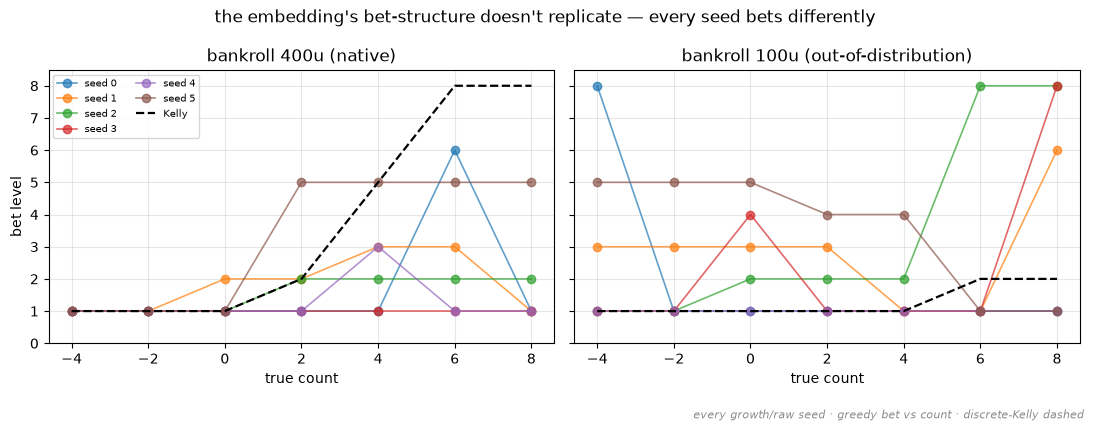

In [4]:
plot_bet_replication("growth", "raw", bankrolls=(400, 100),
                     note="every growth/raw seed · greedy bet vs count · discrete-Kelly dashed")

The reads don't survive. At the **native** 400u the seeds range from dead-flat (seed 3 — the one the
embedding above came from) through coarse gating (seed 5) to erratic (seed 0), and *none* is the Kelly ramp.
Off-distribution the disagreement is worse: some seeds rise with count, some fall, some saturate — all of
them wildly over-betting the (nearly flat) low-bankroll Kelly. The clean structure in that single embedding
was **one seed's idiosyncrasy**, not a policy. An embedding is *suggestive, not decisive* — which is exactly
why the next step stops interpreting pictures and runs a controlled experiment.

## 4.3 The controlled test — remove wealth entirely

An embedding is suggestive, not decisive, and we had just been burned reading one. So we ran the
controlled experiment. The bet encoder was made configurable — `--bankroll-feature`:

- **`raw`** — the original: bankroll fed to the network as-is,
- **`logratio`** — bankroll as `log(current / start)`, a scale-free wealth signal,
- **`none`** — **bankroll removed from the input entirely.**

If the agent keyed on wealth, `none` should behave *differently* — it can no longer see wealth at all. This
turns "it keyed on wealth" from an interpretation of a picture into a prediction we can test. (The bet-curves just below are one seed's — per §4.2, read them as illustration only; the *decisive* test is the four-axis result across all seeds, §4.4.)

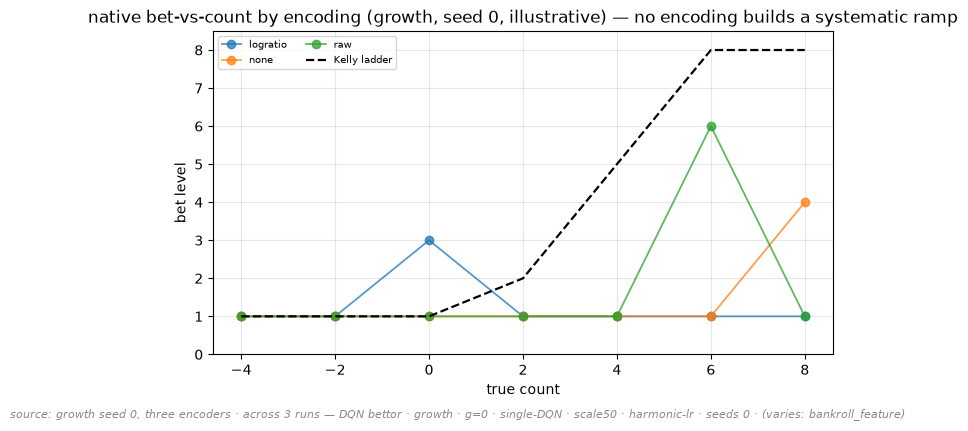

In [5]:
seed0 = runs[(runs.regime == "growth") & (runs.seed == 0)].groupby("bankroll_feature", as_index=False).tail(1)
plot_native_curves(seed0.sort_values("bankroll_feature"), label=lambda r: r.bankroll_feature,
                   title="native bet-vs-count by encoding (growth, seed 0, illustrative) — no encoding builds a systematic ramp",
                   note=bet_provenance(seed0, role="growth seed 0, three encoders"))

## 4.4 Falsified — the encoding doesn't matter

The four-axis growth, across seeds, for all three encoders against the baselines. **`none` is
statistically identical to `raw`** (−0.19 ± 0.04 vs −0.19 ± 0.08 ×10⁻⁴), and `logratio` is no better. All
three sit at **≈ Flat**. Removing wealth from the input changes *nothing*.

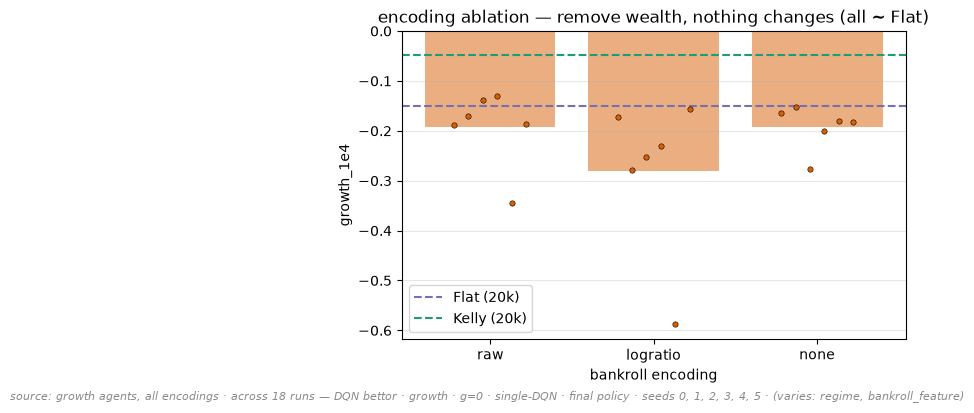

In [6]:
plot_encoding_ablation(evals, note=bet_provenance(evals[(evals.train_regime=='growth')&(evals.bettor=='agent')&(evals.phase=='final')], role="growth agents, all encodings"))

In [7]:
display(coverage_visitation("growth"))   # fixed vs cover: % of hands played in the never-trained band (< 200u)

,bettor,min,p50,max,frac_starved_pct
0,cover,1.5,345.0,816.5,25.93
1,fixed,173.5,401.0,555.0,0.05


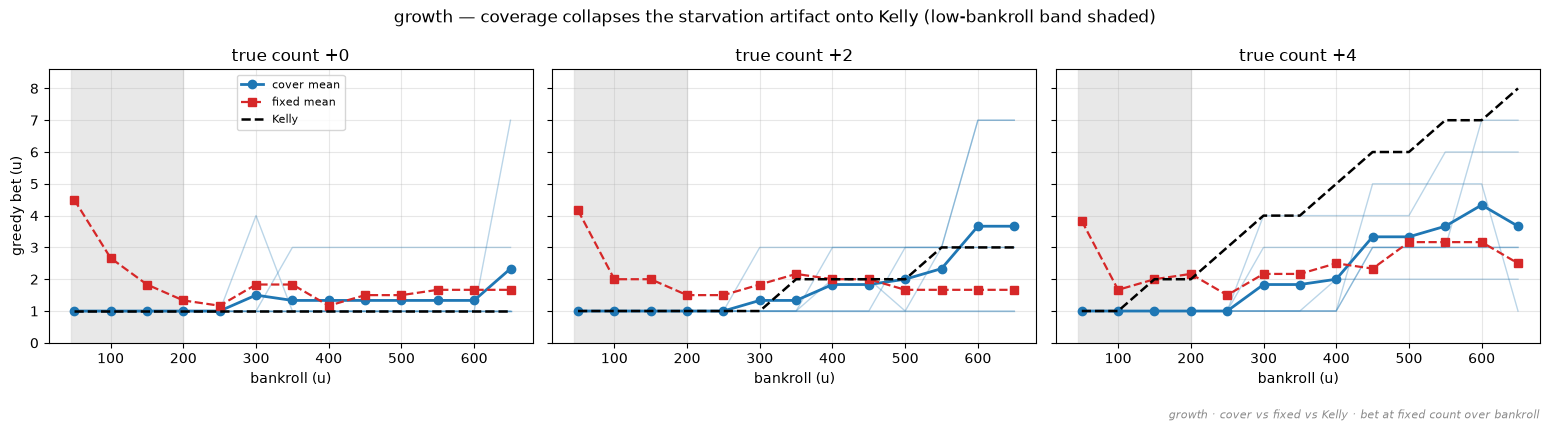

In [8]:
plot_bet_coverage("growth", note="growth · cover vs fixed vs Kelly · bet at fixed count over bankroll")

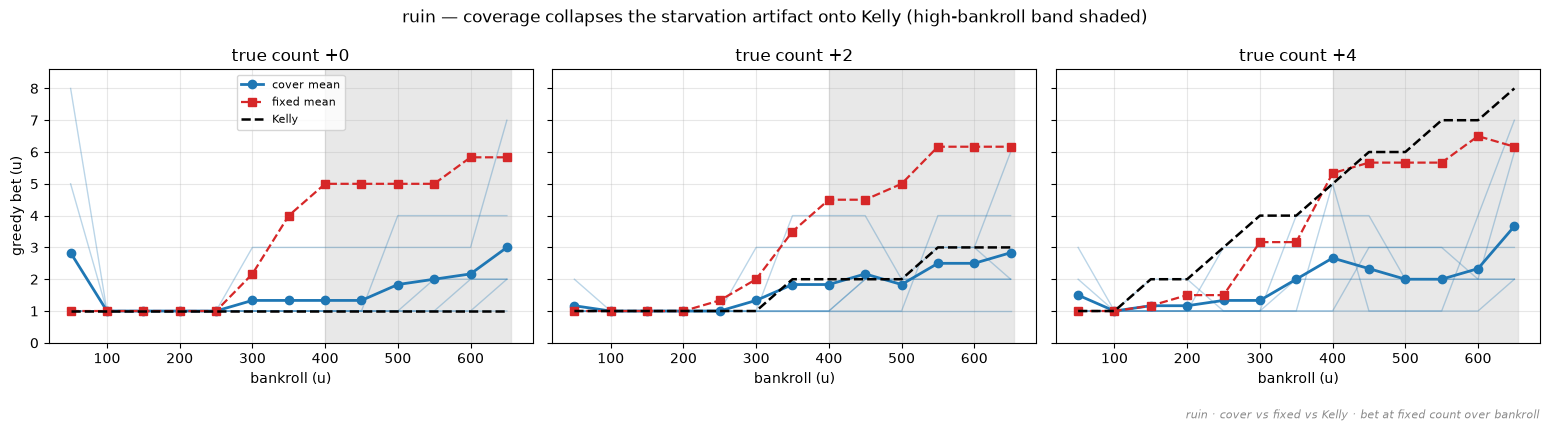

In [9]:
plot_bet_coverage("ruin", note="ruin · cover vs fixed vs Kelly · bet at fixed count over bankroll")

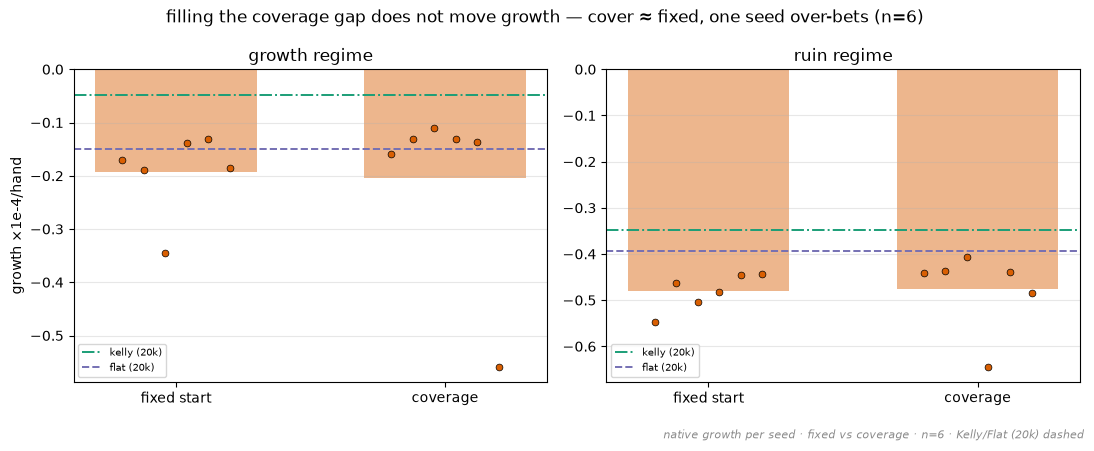

,regime,bettor,n,growth_1e4,growth_sd,ruin_pct,dd_pct
0,growth,kelly,<NA>,-0.048,<NA>,0.00,0.14
1,growth,flat,<NA>,-0.150,<NA>,0.00,0.00
2,growth,agent-fixed,6,-0.193,0.078,0.00,0.18
3,growth,agent-cover,6,-0.204,0.175,0.00,0.03
4,ruin,kelly,<NA>,-0.348,<NA>,0.00,2.34
5,ruin,flat,<NA>,-0.395,<NA>,0.00,0.80
6,ruin,agent-fixed,6,-0.481,0.039,0.03,1.39
7,ruin,agent-cover,6,-0.476,0.087,0.02,1.38


growth {'regime': 'growth', 'fixed': -0.193, 'cover': -0.204, 'gap': -0.011, 'z': -0.14, 'p': 0.8882, 'n_cover': 6, 'n_fixed': 6}
ruin {'regime': 'ruin', 'fixed': -0.481, 'cover': -0.476, 'gap': 0.005, 'z': 0.13, 'p': 0.8978, 'n_cover': 6, 'n_fixed': 6}


In [10]:
plot_coverage_growth(note="native growth per seed · fixed vs coverage · n=6 · Kelly/Flat (20k) dashed")
display(coverage_four_axis())
for r in ("growth", "ruin"):
    print(r, coverage_growth_ztest(r))

## 4.6 What this closes

Two independent tests, pointing the same way. **Remove** wealth from the input (§4.3–4.4) and nothing
changes — the agent that cannot see its bankroll at all still bets ≈ Flat, so wealth was never load-bearing.
**Fill in** the wealth the agent never saw (§4.5) and the mirror in the embedding dissolves — it *was*
extrapolation — yet performance still does not move: the one wealth-shaped thing the network did was an
artifact, and erasing it is cosmetic. From both sides the answer is the same: the wall is not the
representation. It is the **thin, sub-noise edge of Chapter 3**.

The arc matters as much as the result. We formed a hypothesis, found apparent support in an embedding,
**caught our own over-reading** — out-of-distribution and unreplicated — then settled it with two controlled
experiments, and even inside the second one caught a small-sample result that did not survive more seeds.
That is the evaluator's job: not to reach a verdict, but to keep trying to break your own. Chapter 5 draws
the threads together.